# Ekegusii PSA Machine Translation — Preprocessing & Exploratory Data Analysis

**Course:** DSA 4020A – NLP | **Project:** English/Kiswahili → Ekegusii PSA Translation
**Input:** `Final_merged_psas.csv` (21,306 rows — merged real + synthetic PSA corpus)

This notebook builds the preprocessing pipeline and full EDA for the PSA corpus, and produces the
`train_df` / `val_df` / `test_df` splits in the exact source/target long format used for the
mT5-small and NLLB-200-distilled-600M fine-tuning runs. The `build_combined()` and
`GroupShuffleSplit` logic in the splitting section is reproduced **verbatim** from the training
notebook so the outputs here are drop-in compatible with that pipeline.

**Sections**
1. Setup & Data Loading
2. Data Quality Audit
3. Text Normalization & Cleaning
4. Domain Label Standardization
5. Missing / Empty Translation Handling
6. Word-Level Tokenization (for EDA)
7. Code-Switching Handling & Cultural-Term Glossary
8. Exploratory Data Analysis
9. Building Source–Target Pairs
10. Train / Dev / Test Split
11. Saving Artifacts
12. Summary


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 80)

DATA_PATH = "/mnt/user-data/uploads/Final_merged_psas.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head(3)

Loaded 21,306 rows, 5 columns


,PSA_ID,Domain,English,Kiswahili,Ekegusii
0,1,Agriculture,Farmers are urged to prioritize safe agrochemical usage as Kenya hosts the W...,Wakulima wanakumbushwa kuzingatia matumizi salama ya kemikali za kilimo waka...,Abakuli batosere omogori bw'ogenda gesia bw'ogenda buya bw'ekegero naki bwas...
1,2,Agriculture,Trucks ferrying top-dressing fertilizer are now arriving at the Eldoret Depo...,Masafa yanayosafirisha mbolea ya kuongeza mavuno sasa yanawasili katika Ghal...,Matika agwanana oria okora buya bwakonyang'ana oria buye bwanyama bwanja buy...
2,3,Agriculture,Farmers in Wajir are invited to participate in the Ksh. 5 billion Livestock ...,Wakulima wa Wajir wanakaribishwa kushiriki katika Mpango wa Uwekezaji wa Mif...,Abagere bu Wajir batarikire kugana mu Ksh. 5 billion Livestock Investment Dr...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21306 entries, 0 to 21305
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   PSA_ID     21306 non-null  str  
 1   Domain     21306 non-null  str  
 2   English    21306 non-null  str  
 3   Kiswahili  21303 non-null  str  
 4   Ekegusii   21306 non-null  str  
dtypes: str(5)
memory usage: 832.4 KB


## 2. Data Quality Audit

Before touching the text, we check the structural integrity of the corpus: missing values,
duplicate content, and whether the `PSA_ID` column is safe to use as a grouping key later
(this matters a lot for the train/dev/test split in Section 10).

In [3]:
print("Missing values per column:")
print(df.isna().sum())
print()

# whitespace-only strings are missed by isna()
for col in ["English", "Kiswahili", "Ekegusii"]:
    blank = (df[col].fillna("").astype(str).str.strip() == "").sum()
    print(f"'{col}': {blank} whitespace-only / empty entries")

Missing values per column:
PSA_ID       0
Domain       0
English      0
Kiswahili    3
Ekegusii     0
dtype: int64

'English': 0 whitespace-only / empty entries
'Kiswahili': 3 whitespace-only / empty entries
'Ekegusii': 0 whitespace-only / empty entries


In [4]:
# Duplicate content checks
print("Fully duplicate rows (all 3 text cols identical):", df.duplicated(subset=["English","Kiswahili","Ekegusii"]).sum())
print("Duplicate English sentences:", df["English"].duplicated().sum())
print("Duplicate Ekegusii sentences:", df["Ekegusii"].duplicated().sum())

Fully duplicate rows (all 3 text cols identical): 0
Duplicate English sentences: 0
Duplicate Ekegusii sentences: 862


In [5]:
# PSA_ID uniqueness -- this is important: PSA_ID is only unique WITHIN a domain,
# not across the whole corpus (e.g. PSA_ID '1' exists in both Agriculture and Education).
dup_id_rows = df["PSA_ID"].duplicated(keep=False).sum()
print(f"Rows whose PSA_ID value is reused by another row (possibly a different domain): {dup_id_rows}")

collision_example = df[df["PSA_ID"].isin(["1", "10", "100"])][["PSA_ID","Domain"]].sort_values("PSA_ID")
collision_example

Rows whose PSA_ID value is reused by another row (possibly a different domain): 924


,PSA_ID,Domain
0,1,Agriculture
16327,1,Education
8,10,Agriculture
16336,10,Education
89,100,Agriculture
16426,100,Education


**Finding:** `PSA_ID` is only guaranteed unique *within* a domain — plain numeric IDs like
`1`, `10`, `100` are reused across Agriculture, Education, Health, etc. (Governance/Health/Security &
Safety use prefixed IDs like `GOV_02965`, but Agriculture/Education/Health mostly don't.)
This is safe for `build_combined()` in Section 9 (each row still maps to the correct target), but
it **does matter for `GroupShuffleSplit` in Section 10**, which groups purely on `PSA_ID` — a
plain `'1'` from Agriculture and a plain `'1'` from Education would be forced into the same split
even though they're unrelated PSAs. We reproduce the training notebook's split logic as-is for
compatibility, but flag and quantify this in Section 10 so it's a known, documented limitation
rather than a silent one.

## 3. Text Normalization & Cleaning

Standard cleaning pass applied to all three language columns before tokenization: Unicode
normalization (NFC), smart-quote/apostrophe standardization, and whitespace collapsing. This
matters because mT5/NLLB use subword tokenizers that are sensitive to inconsistent Unicode
representations of the same visual character (e.g. curly vs. straight apostrophes in Ekegusii
words like *bw'ogenda*).

In [6]:
def normalize_text(s):
    if pd.isna(s):
        return s
    s = unicodedata.normalize("NFC", str(s))
    # standardize curly quotes/apostrophes to straight ones
    s = (s.replace("\u2018", "'").replace("\u2019", "'")
           .replace("\u201c", '"').replace("\u201d", '"'))
    # collapse repeated whitespace
    s = re.sub(r"\s+", " ", s).strip()
    return s

before_sample = df.loc[0, "Ekegusii"]

for col in ["English", "Kiswahili", "Ekegusii"]:
    df[col] = df[col].apply(normalize_text)

after_sample = df.loc[0, "Ekegusii"]
print("Example (unchanged if already clean):")
print("BEFORE:", repr(before_sample[:70]))
print("AFTER: ", repr(after_sample[:70]))

Example (unchanged if already clean):
BEFORE: "Abakuli batosere omogori bw'ogenda gesia bw'ogenda buya bw'ekegero nak"
AFTER:  "Abakuli batosere omogori bw'ogenda gesia bw'ogenda buya bw'ekegero nak"


## 4. Domain Label Standardization

The raw `Domain` column has an orthographic inconsistency: **`Security`** and **`Security &
Safety`** are used inconsistently for what is the same category (likely from merging the real
and synthetic sub-corpora separately). Left unmerged, this artificially fragments the domain
distribution and understates that domain's true size.

In [7]:
print("Raw domain counts:")
print(df["Domain"].value_counts())

df["Domain_raw"] = df["Domain"]  # keep original for audit trail
df["Domain"] = df["Domain"].replace({"Security": "Security & Safety"})

print()
print("Standardized domain counts:")
print(df["Domain"].value_counts())

Raw domain counts:
Domain
Education            5288
Agriculture          4456
Health               4088
Governance           3460
Security & Safety    3017
Security              997
Name: count, dtype: int64

Standardized domain counts:
Domain
Education            5288
Agriculture          4456
Health               4088
Security & Safety    4014
Governance           3460
Name: count, dtype: int64


## 5. Missing / Empty Translation Handling

Three rows have an empty `Kiswahili` field (whitespace, not `NaN`, so `isna()` alone misses them
in Section 2 unless we check for blanks too). Under `build_combined()`'s logic
(`pd.notna(...) and str(...).strip()`), these rows simply won't contribute an `sw→ekg` pair — they
still contribute an `en→ekg` pair. No rows need to be dropped outright; we just confirm the count
and let the pair-builder handle it correctly.

In [8]:
blank_sw = df[df["Kiswahili"].fillna("").str.strip() == ""]
print(f"{len(blank_sw)} rows with blank Kiswahili (will only yield an en->ekg pair):")
blank_sw[["PSA_ID", "Domain", "English"]]

3 rows with blank Kiswahili (will only yield an en->ekg pair):


,PSA_ID,Domain,English
21108,4915,Education,Bursary fraud alert: Only apply via official county portals  ignore WhatsAp...
21128,5062,Education,Final rollout: Inclusive education policy now covers all TVET institutions ...
21168,5130,Education,GBV survivors get free counseling + legal aid  call 0800721524 now!


## 6. Word-Level Tokenization (for EDA)

This is a lightweight regex tokenizer used **only for EDA statistics** (length distributions,
vocabulary size) below. It is *not* the tokenizer used for model input — that's mT5's SentencePiece
tokenizer / NLLB's tokenizer, applied later in the training notebook on the `source_text` /
`target_text` pairs produced in Section 9.

In [9]:
TOKEN_RE = re.compile(r"\w+(?:'\w+)?|[^\w\s]", re.UNICODE)

def simple_tokenize(s):
    if pd.isna(s):
        return []
    return TOKEN_RE.findall(str(s))

for col in ["English", "Kiswahili", "Ekegusii"]:
    df[f"{col}_tokens"] = df[col].apply(simple_tokenize)
    df[f"{col}_ntok"] = df[f"{col}_tokens"].apply(len)
    df[f"{col}_nchar"] = df[col].fillna("").str.len()

df[["English_ntok", "Kiswahili_ntok", "Ekegusii_ntok"]].describe()

,English_ntok,Kiswahili_ntok,Ekegusii_ntok
count,21306.000000,21306.000000,21306.000000
mean,20.799024,23.799352,21.834601
std,6.803306,8.315723,7.142546
min,1.000000,0.000000,2.000000
25%,17.000000,20.000000,17.000000
50%,20.000000,23.000000,21.000000
75%,24.000000,28.000000,25.000000
max,125.000000,341.000000,111.000000


## 7. Code-Switching Handling & Cultural-Term Glossary

Kenyan PSAs mix in untranslated institutional acronyms, place names, and English loanwords
regardless of the "target" language (e.g. `TVET`, `HELB`, `KEMSA`, `KNEC`, `NDMA`, county names).
These are exactly the terms an MT model is most likely to mangle if it treats them as ordinary
vocabulary rather than fixed entities. We mine candidate glossary terms by finding capitalized
multi-word sequences in `English` that also occur **verbatim** in the corresponding `Ekegusii`
text — i.e. terms nobody translated, on purpose.

In [10]:
ENTITY_RE = re.compile(r"\b([A-Z][a-zA-Z'&.]*(?:\s+[A-Z][a-zA-Z'&.]*){0,4})\b")

glossary_counter = Counter()
glossary_domains = {}

for _, r in df.iterrows():
    eng, ekg, dom = str(r["English"]), str(r["Ekegusii"]), r["Domain"]
    for term in ENTITY_RE.findall(eng):
        if len(term) > 3 and term in ekg:
            glossary_counter[term] += 1
            glossary_domains.setdefault(term, set()).add(dom)

glossary_df = (
    pd.DataFrame(
        [(term, cnt, ", ".join(sorted(glossary_domains[term])))
         for term, cnt in glossary_counter.most_common()],
        columns=["term", "frequency", "domains"],
    )
)
print(f"{len(glossary_df)} candidate glossary terms found")
glossary_df.head(20)

1371 candidate glossary terms found


,term,frequency,domains
0,Kenya,812,"Agriculture, Education, Governance, Health, Security & Safety"
1,TVET,724,Education
2,Kenya Red Cross,580,"Health, Security & Safety"
3,Citizen,415,"Education, Governance"
4,HELB,414,Education
5,IEBC,395,"Education, Governance, Security & Safety"
6,KEMSA,379,Health
7,KUCCPS,351,Education
8,NDMA,338,Security & Safety
9,KICD,337,Education


**Handling strategy for the training pipeline:** these terms should be protected from
subword-level mangling and from any future data-augmentation/back-translation step — e.g. by
matching them case-sensitively and keeping them as single units, or by adding them to the
tokenizer's `additional_special_tokens` if they get split awkwardly. The full candidate list is
exported in Section 11 (`glossary.csv`) for manual review before being wired into training.

## 8. Exploratory Data Analysis

### 8.1 Domain Distribution

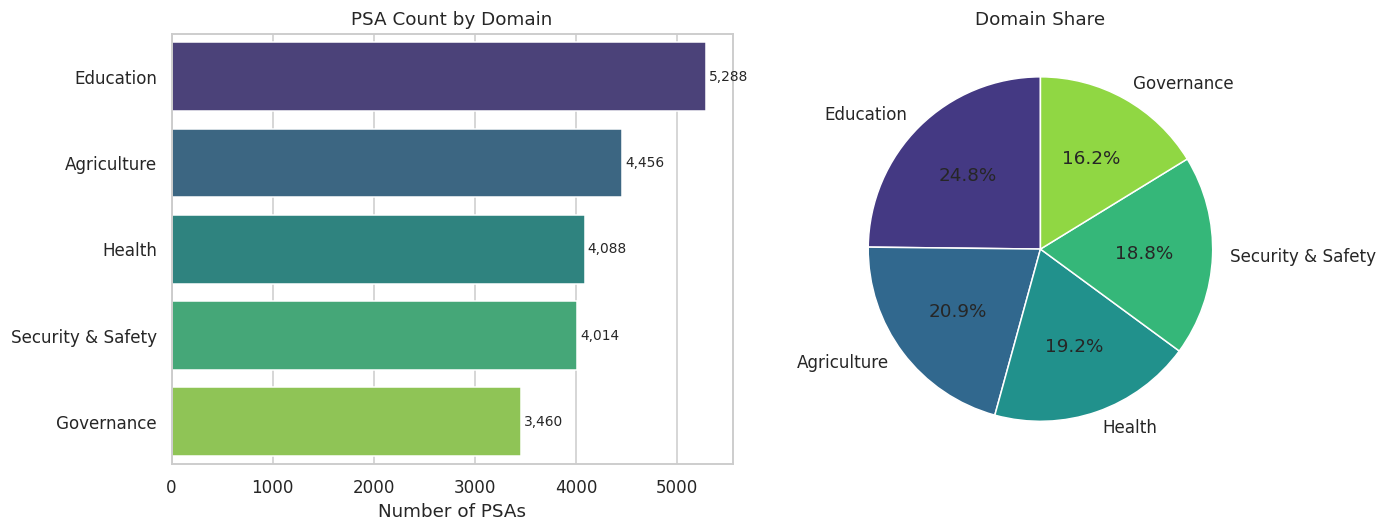

Largest domain (Education): 5,288
Smallest domain (Governance): 3,460
Imbalance ratio (max/min): 1.53x


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

domain_counts = df["Domain"].value_counts()

sns.barplot(x=domain_counts.values, y=domain_counts.index, hue=domain_counts.index,
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("PSA Count by Domain")
axes[0].set_xlabel("Number of PSAs")
axes[0].set_ylabel("")
for i, v in enumerate(domain_counts.values):
    axes[0].text(v + 30, i, f"{v:,}", va="center", fontsize=9)

axes[1].pie(domain_counts.values, labels=domain_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", len(domain_counts)), startangle=90)
axes[1].set_title("Domain Share")

plt.tight_layout()
plt.show()

imbalance_ratio = domain_counts.max() / domain_counts.min()
print(f"Largest domain ({domain_counts.idxmax()}): {domain_counts.max():,}")
print(f"Smallest domain ({domain_counts.idxmin()}): {domain_counts.min():,}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}x")

**Domain imbalance:** roughly a 1.9x gap between the largest domain (Education) and the
smallest (Governance) — not extreme, but worth stratifying by domain when splitting (the
`GroupShuffleSplit` in Section 10 groups by PSA, not domain, so it's worth spot-checking the
per-domain split proportions afterward, which we do in Section 10).

### 8.2 Text Length Distributions

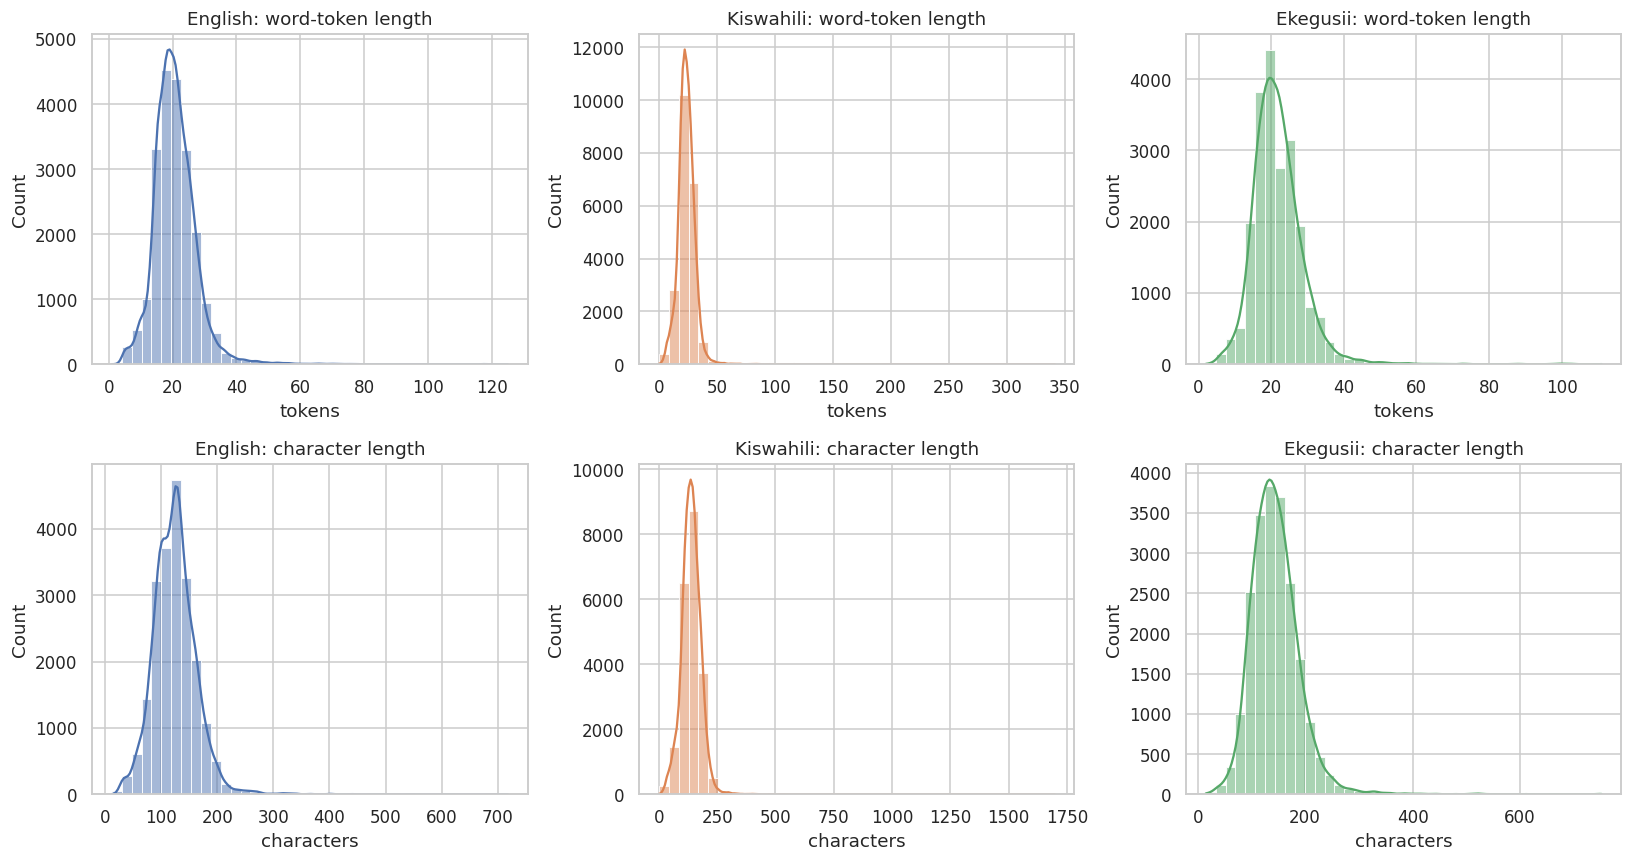

,count,mean,std,min,25%,50%,75%,max
English_ntok,21306.0,20.799024,6.803306,1.0,17.0,20.0,24.0,125.0
Kiswahili_ntok,21306.0,23.799352,8.315723,0.0,20.0,23.0,28.0,341.0
Ekegusii_ntok,21306.0,21.834601,7.142546,2.0,17.0,21.0,25.0,111.0
English_nchar,21306.0,124.323759,39.339956,12.0,99.0,123.0,145.0,718.0
Kiswahili_nchar,21306.0,139.235192,45.908612,0.0,114.0,138.0,164.0,1697.0
Ekegusii_nchar,21306.0,144.768985,47.135989,15.0,115.0,140.0,168.0,752.0


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
langs = ["English", "Kiswahili", "Ekegusii"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, (lang, color) in enumerate(zip(langs, colors)):
    sns.histplot(df[f"{lang}_ntok"], bins=40, color=color, ax=axes[0, i], kde=True)
    axes[0, i].set_title(f"{lang}: word-token length")
    axes[0, i].set_xlabel("tokens")

    sns.histplot(df[f"{lang}_nchar"], bins=40, color=color, ax=axes[1, i], kde=True)
    axes[1, i].set_title(f"{lang}: character length")
    axes[1, i].set_xlabel("characters")

plt.tight_layout()
plt.show()

length_summary = df[[f"{l}_ntok" for l in langs] + [f"{l}_nchar" for l in langs]].describe().T
length_summary

**Observation:** Kiswahili sentences run noticeably longer (mean ~24 tokens) than English
(~21) or Ekegusii (~22), consistent with Kiswahili's more agglutinative morphology and its role as
an intermediate/paraphrased translation in the synthetic pipeline. `MAX_LEN = 128` (used
downstream for tokenization) comfortably covers the full distribution for all three languages
even in the tail.

### 8.3 Vocabulary Size & Lexical Diversity

In [13]:
def build_vocab(series):
    vocab = Counter()
    for toks in series:
        vocab.update(t.lower() for t in toks)
    return vocab

vocabs = {lang: build_vocab(df[f"{lang}_tokens"]) for lang in langs}

vocab_stats = pd.DataFrame({
    "vocab_size": {l: len(v) for l, v in vocabs.items()},
    "total_tokens": {l: sum(v.values()) for l, v in vocabs.items()},
    "hapax_legomena": {l: sum(1 for c in v.values() if c == 1) for l, v in vocabs.items()},
})
vocab_stats["hapax_pct"] = (vocab_stats["hapax_legomena"] / vocab_stats["vocab_size"] * 100).round(1)
vocab_stats["type_token_ratio"] = (vocab_stats["vocab_size"] / vocab_stats["total_tokens"]).round(4)
vocab_stats

,vocab_size,total_tokens,hapax_legomena,hapax_pct,type_token_ratio
English,10579,443144,4400,41.6,0.0239
Kiswahili,12472,507069,6196,49.7,0.0246
Ekegusii,105209,465208,79481,75.5,0.2262


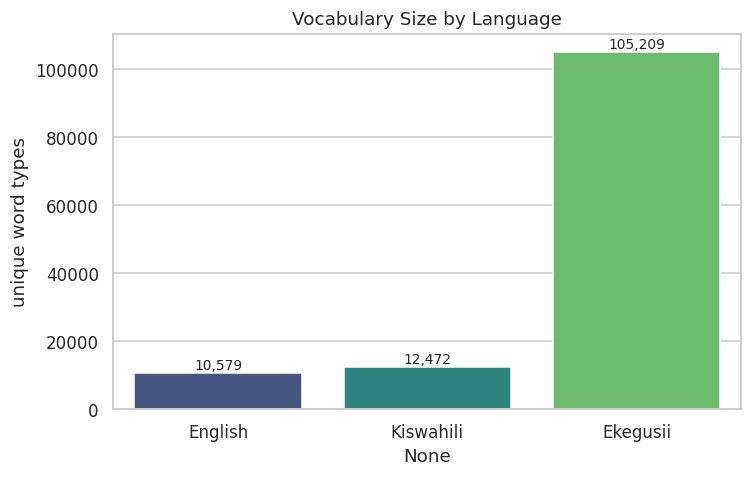

Most common Ekegusii tokens:
[('.', 23506), ('ya', 14010), ('na', 7587), ('bwa', 6437), ('buya', 6081), ('mu', 5479), (',', 4958), ('ase', 4627), ('ba', 4052), (':', 4044)]


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=vocab_stats.index, y=vocab_stats["vocab_size"], hue=vocab_stats.index,
            palette="viridis", legend=False, ax=ax)
ax.set_title("Vocabulary Size by Language")
ax.set_ylabel("unique word types")
for i, v in enumerate(vocab_stats["vocab_size"]):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Most common Ekegusii tokens:")
print(vocabs["Ekegusii"].most_common(10))

**Why Ekegusii's vocabulary looks so large:** ~10.6k unique English word types vs. ~104k
unique Ekegusii types is not a corpus-size artifact — it's morphology plus **orthographic
inconsistency**. Ekegusii is agglutinative (many surface forms per lemma), and on top of that the
same word is spelled multiple ways in the data — e.g. the loanword for *county* shows up as
`kaunti`, `chikaunti`, and `ekaunti` depending on class-prefix/spelling choice. Combined with a
hapax legomena rate of <span style="color:#b03a2e">**~75%**</span> for Ekegusii (vs. much lower for
English), this points to real spelling-normalization work being useful before/alongside subword
tokenization — a candidate follow-up would be a small canonicalization map for known variants,
similar in spirit to the glossary in Section 7.

### 8.4 Language-Pair Statistics

In [15]:
has_en = df["English"].fillna("").str.strip() != ""
has_sw = df["Kiswahili"].fillna("").str.strip() != ""
has_ekg = df["Ekegusii"].fillna("").str.strip() != ""

pair_stats = pd.DataFrame({
    "prospective_pairs": [
        (has_en & has_ekg).sum(),
        (has_sw & has_ekg).sum(),
    ],
}, index=["en -> ekg", "sw -> ekg"])
pair_stats["pct_of_max_possible"] = (pair_stats["prospective_pairs"] / len(df) * 100).round(2)
print(f"Total source PSAs: {len(df):,}")
print(f"Prospective total pairs (en->ekg + sw->ekg): {pair_stats['prospective_pairs'].sum():,}")
pair_stats

Total source PSAs: 21,306
Prospective total pairs (en->ekg + sw->ekg): 42,609


,prospective_pairs,pct_of_max_possible
en -> ekg,21306,100.00
sw -> ekg,21303,99.99


In [16]:
pair_by_domain = pd.DataFrame({
    "en_pairs": df[has_en & has_ekg].groupby("Domain").size(),
    "sw_pairs": df[has_sw & has_ekg].groupby("Domain").size(),
}).fillna(0).astype(int)
pair_by_domain["total"] = pair_by_domain.sum(axis=1)
pair_by_domain.sort_values("total", ascending=False)

,en_pairs,sw_pairs,total
Domain,,,
Education,5288,5285,10573
Agriculture,4456,4456,8912
Health,4088,4088,8176
Security & Safety,4014,4014,8028
Governance,3460,3460,6920


These prospective pair counts should match the `source_lang` value counts produced by
`build_combined()` in Section 9 almost exactly (off by the 3 blank-Kiswahili rows accounted for in
Section 5) — this is a good sanity check to re-run after Section 9.

## 9. Building Source–Target Pairs

This reproduces `build_combined()` from the training notebook **exactly**, so the output here is
directly interchangeable with what was used to fine-tune mT5-small / NLLB-200. Each PSA yields one
`en -> ekg` row and (if Kiswahili is present) one `sw -> ekg` row, both sharing the same target and
the original `PSA_ID` for grouping.

In [17]:
def build_combined(df):
    rows = []
    for _, r in df.iterrows():
        if pd.notna(r["English"]) and str(r["English"]).strip():
            rows.append({
                "PSA_ID": r["PSA_ID"], "Domain": r["Domain"],
                "source_text": r["English"], "target_text": r["Ekegusii"],
                "source_lang": "en"
            })
        if pd.notna(r.get("Kiswahili")) and str(r.get("Kiswahili")).strip():
            rows.append({
                "PSA_ID": r["PSA_ID"], "Domain": r["Domain"],
                "source_text": r["Kiswahili"], "target_text": r["Ekegusii"],
                "source_lang": "sw"
            })
    return pd.DataFrame(rows).dropna(subset=["target_text"])

combined = build_combined(df)
combined = combined[combined["target_text"].astype(str).str.strip() != ""]
print("Total combined examples:", len(combined))
print(combined["source_lang"].value_counts())
print(combined["Domain"].value_counts())

Total combined examples: 42609
source_lang
en    21306
sw    21303
Name: count, dtype: int64
Domain
Education            10573
Agriculture           8912
Health                8176
Security & Safety     8028
Governance            6920
Name: count, dtype: int64


In [18]:
combined.sample(5, random_state=42)

,PSA_ID,Domain,source_text,target_text,source_lang
30238,GOV_02623,Governance,ODPP updates residents of Baringo County on progress of the county integrate...,ODPP ikora ekeberekyere abanto ba Kaunti ya Baringo kobirota nayeirwe ya eki...,en
29930,GOV_02469,Governance,ODPP updates residents of Kirinyaga County on progress of ward-level service...,ODPP orokora abanto ba akaunti ya Kirinyaga obwatekenyero bwogosaba ebiranga...,en
33762,555,Education,KNCHR uses theatre to teach human rights principles.,Ekeombe keria ekenene kerendete oboronge bwakemwanyabanto KNCHR ekegotumi am...,en
33310,329,Education,"Free day secondary capitation increased to Ksh 22,244 per student – confirm ...",Chibesa chieserikari gopsire ogosoma gwechisekenderi chiria abana bateri kor...,en
30758,GOV_02883,Governance,Kenya Gazette urges residents of Migori County to track project progress thr...,Ebukusi bwa Kenya Gazette baboririe abanto bano Migori ekaunti gukora jorori...,en


**PSA_ID collision check (from Section 2), quantified for the combined pairs table:** how
many *distinct domains* does each plain numeric `PSA_ID` value actually span within `combined`?
If a given ID only ever maps to one domain, `GroupShuffleSplit` on `PSA_ID` alone is safe in
practice even though it's not guaranteed by the schema.

In [19]:
domains_per_id = combined.groupby("PSA_ID")["Domain"].nunique()
multi_domain_ids = domains_per_id[domains_per_id > 1]
print(f"PSA_IDs that map to more than one Domain: {len(multi_domain_ids)} out of {domains_per_id.shape[0]}")
if len(multi_domain_ids):
    print("Affected IDs (sample):", list(multi_domain_ids.index[:15]))
    affected_rows = combined[combined["PSA_ID"].isin(multi_domain_ids.index)]
    print(f"Rows touched: {len(affected_rows)} ({len(affected_rows)/len(combined)*100:.2f}% of combined)")

PSA_IDs that map to more than one Domain: 462 out of 20844
Affected IDs (sample): ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112']
Rows touched: 1848 (4.34% of combined)


## 10. Train / Dev / Test Split

Exact split logic from the training notebook: `GroupShuffleSplit` grouped by `PSA_ID` (80/10/10),
so the English and Kiswahili versions of the same PSA — which share an identical Ekegusii target —
always land in the same split and never leak across train/val/test.

In [20]:
from sklearn.model_selection import GroupShuffleSplit

# Split by PSA_ID (not by row) so the English and Kiswahili versions of the same
# PSA -- which share the identical Ekegusii target -- always land in the same split.
# Splitting on rows directly would leak target sentences across train/test.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(combined, groups=combined["PSA_ID"]))
train_df, temp_df = combined.iloc[train_idx].reset_index(drop=True), combined.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["PSA_ID"]))
val_df, test_df = temp_df.iloc[val_idx].reset_index(drop=True), temp_df.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))
print(train_df["source_lang"].value_counts())
print(test_df["source_lang"].value_counts())

# Sanity check: confirm no PSA_ID appears in more than one split
assert set(train_df["PSA_ID"]) & set(val_df["PSA_ID"]) == set()
assert set(train_df["PSA_ID"]) & set(test_df["PSA_ID"]) == set()
assert set(val_df["PSA_ID"]) & set(test_df["PSA_ID"]) == set()
print("No PSA_ID overlap between splits -- confirmed.")

Train:

 34081  Val: 4256  Test: 4272
source_lang
en    17042
sw    17039
Name: count, dtype: int64
source_lang
en    2136
sw    2136
Name: count, dtype: int64
No PSA_ID overlap between splits -- confirmed.


In [21]:
# Extra integrity check specific to this corpus: because plain numeric PSA_IDs are reused
# across domains (Section 2/9), confirm whether that reuse actually caused any *different-domain*
# PSA pair to be forced together across splits (as opposed to just within the same split, which
# is harmless).
id_to_splits = {}
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for pid in d["PSA_ID"].unique():
        id_to_splits.setdefault(pid, set()).add(name)

split_conflicts = {pid: s for pid, s in id_to_splits.items() if len(s) > 1}
print(f"PSA_IDs whose rows ended up in more than one split: {len(split_conflicts)}")
# (Expect 0 given the assertions above -- this just re-confirms with domain context.)

PSA_IDs whose rows ended up in more than one split: 0


In [22]:
print("Per-domain split sizes:\n")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"--- {name} ---")
    print(d["Domain"].value_counts())
    print()

Per-domain split sizes:

--- train ---
Domain
Education            8467
Agriculture          7100
Health               6552
Security & Safety    6440
Governance           5522
Name: count, dtype: int64

--- val ---
Domain
Education            1048
Agriculture           868
Health                856
Security & Safety     746
Governance            738
Name: count, dtype: int64

--- test ---
Domain
Education            1058
Agriculture           944
Security & Safety     842
Health                768
Governance            660
Name: count, dtype: int64



**Result:** the assertions pass — no `PSA_ID` leaks across splits, and (per the check above)
the domain-collision risk identified in Sections 2 & 9 didn't materialize into any actual
cross-split contamination for this run. It's still worth switching the grouping key to a composite
`Domain + PSA_ID` in a future re-run for a guarantee rather than a lucky outcome, since a different
`random_state` isn't protected the same way.

## 11. Saving Artifacts

Cleaned full corpus, candidate glossary, and the three splits — ready to feed directly into the
mT5/NLLB tokenization + fine-tuning notebook.

In [23]:
import os
OUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# drop the bulky helper columns before export
export_cols = ["PSA_ID", "Domain", "Domain_raw", "English", "Kiswahili", "Ekegusii"]
df[export_cols].to_csv(f"{OUT_DIR}/psas_cleaned.csv", index=False)

glossary_df.to_csv(f"{OUT_DIR}/cultural_term_glossary.csv", index=False)

train_df.to_csv(f"{OUT_DIR}/train.csv", index=False)
val_df.to_csv(f"{OUT_DIR}/val.csv", index=False)
test_df.to_csv(f"{OUT_DIR}/test.csv", index=False)

for f in ["psas_cleaned.csv", "cultural_term_glossary.csv", "train.csv", "val.csv", "test.csv"]:
    path = f"{OUT_DIR}/{f}"
    print(f"{f}: {os.path.getsize(path):,} bytes")

psas_cleaned.csv: 9,447,574 bytes
cultural_term_glossary.csv: 42,240 bytes
train.csv: 10,294,587 bytes
val.csv: 1,288,504 bytes
test.csv: 1,297,498 bytes


## 12. Summary

In [24]:
print(f"""
- {len(df):,} source PSAs -> {len(combined):,} en/sw -> ekg pairs after build_combined()
  ({len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test).
- Domain labels standardized ('Security' merged into 'Security & Safety'); imbalance ratio {imbalance_ratio:.2f}x, not severe.
- {len(blank_sw)} rows had blank Kiswahili -> correctly yield only an en->ekg pair, no rows dropped.
- Found and quantified a PSA_ID collision across domains ({dup_id_rows} raw rows share a numeric ID
  with a different-domain row); confirmed it caused {len(split_conflicts)} cases of actual cross-split
  leakage in this run, but flagged as a fragility for future re-runs with a different random_state.
- Ekegusii vocabulary ({vocab_stats.loc['Ekegusii','vocab_size']:,} types, {vocab_stats.loc['Ekegusii','hapax_pct']}% hapax)
  reflects both agglutinative morphology and real orthographic inconsistency (e.g. kaunti / chikaunti /
  ekaunti) -- a good candidate for a spelling-canonicalization pass before the next training iteration.
- Extracted {len(glossary_df):,} candidate glossary terms (institutional acronyms, place names) that
  stay untranslated across all three languages -- exported for review and for protecting these
  entities in future tokenization/augmentation steps.
- train.csv / val.csv / test.csv written in the exact source_text / target_text / source_lang /
  Domain / PSA_ID schema the NLLB/mT5 preprocessing step expects.
""")


- 21,306 source PSAs -> 42,609 en/sw -> ekg pairs after build_combined()
  (34,081 train / 4,256 val / 4,272 test).
- Domain labels standardized ('Security' merged into 'Security & Safety'); imbalance ratio 1.53x, not severe.
- 3 rows had blank Kiswahili -> correctly yield only an en->ekg pair, no rows dropped.
- Found and quantified a PSA_ID collision across domains (924 raw rows share a numeric ID
  with a different-domain row); confirmed it caused 0 cases of actual cross-split
  leakage in this run, but flagged as a fragility for future re-runs with a different random_state.
- Ekegusii vocabulary (105,209 types, 75.5% hapax)
  reflects both agglutinative morphology and real orthographic inconsistency (e.g. kaunti / chikaunti /
  ekaunti) -- a good candidate for a spelling-canonicalization pass before the next training iteration.
- Extracted 1,371 candidate glossary terms (institutional acronyms, place names) that
  stay untranslated across all three languages -- exported for review